02_conductance_dynamics.ipynb
compares AMPA conductance buildup in non-overlap vs overlap burst cases.

Chunk #1: Setup and helper functions to extract AMPA conductance over time and summarize conductance dynamics. The summary gives the peak conductance, peak time, and total conductance area for each sequence segment

In [12]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# import from src/
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.inputs import (
    make_sleep_like_sequence,
    make_burst_sequence,
    burst_overlap_duration,
    g_AMPA_vector,
    g_NMDA_vector,
)

from src.dendrite import (
    simulate_dendrite,
    plot_input_raster,
    plot_voltage_traces,
)

here are the two cases we want to compare:
1. Non-overlapping bursts (burst onset step = 3 ms)
2. Failure case (burst onset step = 3.5 ms)

In [13]:
# Shared setup
n_segments = 12
sequence_segments = [5, 6, 7, 8]

T = 120.0
dt = 0.02

# Dendrite parameters
G_NMDA = 20.0
G_KIR = 20.0
G_ax = 1.0

# These are only used if your current simulate_dendrite supports them
G_AMPA = 1.0
G_NMDA_syn = 1.0

# Input timing
start_time = 10.0
weight = 1.0

# Burst parameters
burst_len = 3
isi_ms = 2.0

# Shared plot axes
xlim_raster = (5, 45)
xlim_ampa = (5, 45)
xlim_nmda = (5, 120)
xlim_voltage = (5, 45)

# Adjust these if your current conductance scaling is different
ylim_ampa = (0, 3)
ylim_nmda = (0, 2.5)
ylim_voltage = (-1.1, 1.1)

In [14]:
def run_simulation(events):
    """Run dendrite simulation, compatible with old or new simulate_dendrite signatures."""
    try:
        return simulate_dendrite(
            n_segments=n_segments,
            T=T,
            dt=dt,
            G_NMDA=G_NMDA,
            G_KIR=G_KIR,
            G_ax=G_ax,
            G_AMPA=G_AMPA,
            G_NMDA_syn=G_NMDA_syn,
            ampa_events=events,
        )
    except TypeError:
        return simulate_dendrite(
            n_segments=n_segments,
            T=T,
            dt=dt,
            G_NMDA=G_NMDA,
            G_KIR=G_KIR,
            G_ax=G_ax,
            ampa_events=events,
        )

In [15]:
n_segments = 12
sequence_segments = [5, 6, 7, 8]

T = 120.0
dt = 0.02

G_NMDA = 20.0
G_KIR = 20.0
G_ax = 1.0
G_AMPA = 1.0
G_NMDA_syn = 1.0

start_time = 10.0
weight = 1.0

burst_len = 3
isi_ms = 2.0

In [16]:
def compute_conductance_history(times, n_segments, events, conductance_fn):
    """Compute AMPA or NMDA conductance history."""
    G = np.zeros((len(times), n_segments))

    for i, t in enumerate(times):
        G[i, :] = conductance_fn(float(t), n_segments, events)

    return G


def plot_conductance_history(times, G_hist, segments, title, ylabel, xlim=None):
    """Plot selected conductance traces."""
    plt.figure(figsize=(9, 4))

    for seg in segments:
        plt.plot(times, G_hist[:, int(seg)], label=f"segment {seg}")

    if xlim is not None:
        plt.xlim(*xlim)

    plt.xlabel("time (ms)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()


def summarize_conductance(times, G_hist, segments, title, t_start=0, t_end=None):
    """Print peak and area under conductance traces."""
    if t_end is None:
        t_end = times[-1]

    mask = (times >= t_start) & (times <= t_end)

    print(title)
    print("-" * len(title))

    for seg in segments:
        trace = G_hist[mask, int(seg)]
        area = np.trapz(trace, times[mask])
        peak = np.max(trace)

        print(f"seg {seg}: peak={peak:.3f}, area={area:.3f}")

In [17]:
def plot_input_raster_same_axis(raster, title, xlim=xlim_raster):
    """Input raster with fixed x-axis."""
    plt.figure(figsize=(9, 2.8))

    sorted_segments = sorted(raster.keys())
    for y, seg in enumerate(sorted_segments):
        plt.vlines(raster[seg], y - 0.35, y + 0.35)

    plt.yticks(range(len(sorted_segments)), [f"seg {seg}" for seg in sorted_segments])
    plt.xlabel("time (ms)")
    plt.ylabel("input segment")
    plt.title(title)
    plt.xlim(*xlim)
    plt.tight_layout()
    plt.show()


def plot_voltage_traces_same_axis(times, V_hist, segments, title, xlim=xlim_voltage, ylim=ylim_voltage):
    """Voltage traces with fixed x/y axes."""
    plt.figure(figsize=(9, 4))

    for seg in segments:
        plt.plot(times, V_hist[:, int(seg)], label=f"segment {seg}")

    plt.axhline(0, linestyle="--", linewidth=1, label="threshold = 0")
    plt.xlim(*xlim)
    plt.ylim(*ylim)
    plt.xlabel("time (ms)")
    plt.ylabel("voltage")
    plt.title(title)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()


def compute_conductance_history(times, n_segments, events, conductance_fn):
    """Compute AMPA or NMDA conductance history."""
    G = np.zeros((len(times), n_segments))

    for i, t in enumerate(times):
        G[i, :] = conductance_fn(float(t), n_segments, events)

    return G


def plot_conductance_history(times, G_hist, segments, title, ylabel, xlim=None, ylim=None):
    """Plot selected conductance traces with fixed axes."""
    plt.figure(figsize=(9, 4))

    for seg in segments:
        plt.plot(times, G_hist[:, int(seg)], label=f"segment {seg}")

    if xlim is not None:
        plt.xlim(*xlim)

    if ylim is not None:
        plt.ylim(*ylim)

    plt.xlabel("time (ms)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()


def summarize_conductance(times, G_hist, segments, title, t_start=5, t_end=None):
    """Print peak and area for conductance traces."""
    if t_end is None:
        t_end = times[-1]

    mask = (times >= t_start) & (times <= t_end)

    print(title)
    print("-" * len(title))

    for seg in segments:
        trace = G_hist[mask, int(seg)]
        peak = np.max(trace)
        area = np.trapz(trace, times[mask])
        print(f"seg {seg}: peak={peak:.3f}, area={area:.3f}")

In [18]:
# 1. Single-spike sleep-like sequence
single_events, single_raster = make_sleep_like_sequence(
    sequence_segments=sequence_segments,
    start_time=start_time,
    step_ms=5.0,
    weight=weight,
)

# 2. Wake-like non-overlapping bursts
# Burst span = (burst_len - 1) * isi_ms = 4 ms
# onset_step_ms = 8 ms means no overlap
nonoverlap_onset_step_ms = 8.0

nonoverlap_events, nonoverlap_raster = make_burst_sequence(
    sequence_segments=sequence_segments,
    start_time=start_time,
    onset_step_ms=nonoverlap_onset_step_ms,
    burst_len=burst_len,
    isi_ms=isi_ms,
    weight=weight,
)

# 3. Wake-like overlapping bursts
# onset_step_ms = 0.5 ms gives 3.5 ms overlap
overlap_onset_step_ms = 0.5

overlap_events, overlap_raster = make_burst_sequence(
    sequence_segments=sequence_segments,
    start_time=start_time,
    onset_step_ms=overlap_onset_step_ms,
    burst_len=burst_len,
    isi_ms=isi_ms,
    weight=weight,
)

print("burst span:", (burst_len - 1) * isi_ms, "ms")
print(
    "non-overlap duration:",
    burst_overlap_duration(nonoverlap_onset_step_ms, burst_len, isi_ms),
    "ms",
)
print(
    "overlap-case duration:",
    burst_overlap_duration(overlap_onset_step_ms, burst_len, isi_ms),
    "ms",
)

burst span: 4.0 ms
non-overlap duration: 0.0 ms
overlap-case duration: 3.5 ms


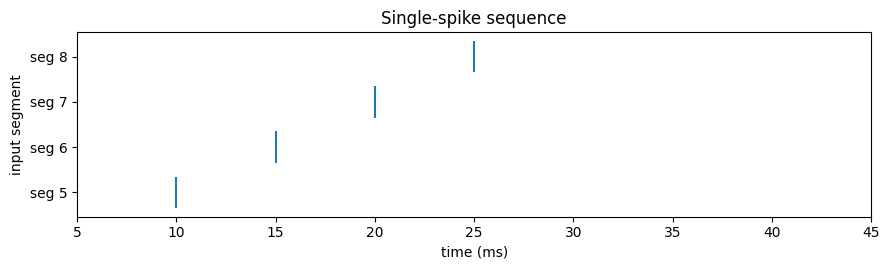

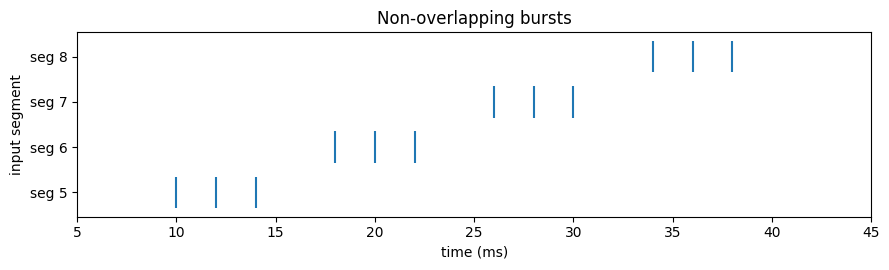

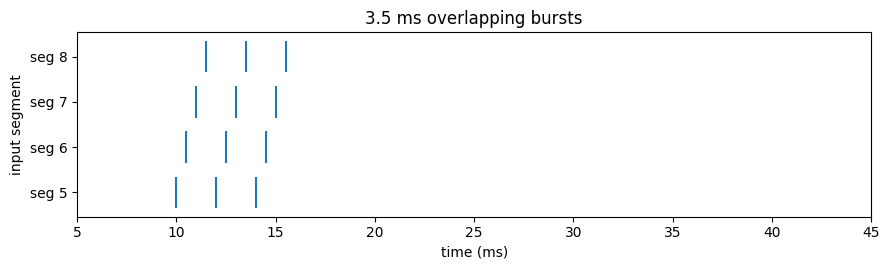

In [19]:
plot_input_raster_same_axis(
    single_raster,
    "Single-spike sequence",
    xlim=xlim_raster,
)

plot_input_raster_same_axis(
    nonoverlap_raster,
    "Non-overlapping bursts",
    xlim=xlim_raster,
)

plot_input_raster_same_axis(
    overlap_raster,
    "3.5 ms overlapping bursts",
    xlim=xlim_raster,
)

In [20]:
times = np.arange(0, T + dt, dt)

# Single-spike conductances
G_ampa_single = compute_conductance_history(
    times,
    n_segments,
    single_events,
    g_AMPA_vector,
)

G_nmda_single = compute_conductance_history(
    times,
    n_segments,
    single_events,
    g_NMDA_vector,
)

# Non-overlap burst conductances
G_ampa_non = compute_conductance_history(
    times,
    n_segments,
    nonoverlap_events,
    g_AMPA_vector,
)

G_nmda_non = compute_conductance_history(
    times,
    n_segments,
    nonoverlap_events,
    g_NMDA_vector,
)

# Overlap burst conductances
G_ampa_overlap = compute_conductance_history(
    times,
    n_segments,
    overlap_events,
    g_AMPA_vector,
)

G_nmda_overlap = compute_conductance_history(
    times,
    n_segments,
    overlap_events,
    g_NMDA_vector,
)

In [21]:
# Shared axis ranges for fair comparisons
xlim_ampa = (5, 45)
xlim_nmda = (5, 120)

# If AMPA is scaled to peak 0.25 and bursts have 3 spikes,
# this gives enough room for accumulation.
ylim_ampa = (0, 3)

# If NMDA is scaled to peak 0.60 and bursts have 3 spikes,
# accumulation can exceed 0.60.
ylim_nmda = (0, 2.0)

plotting the three AMPA conductances

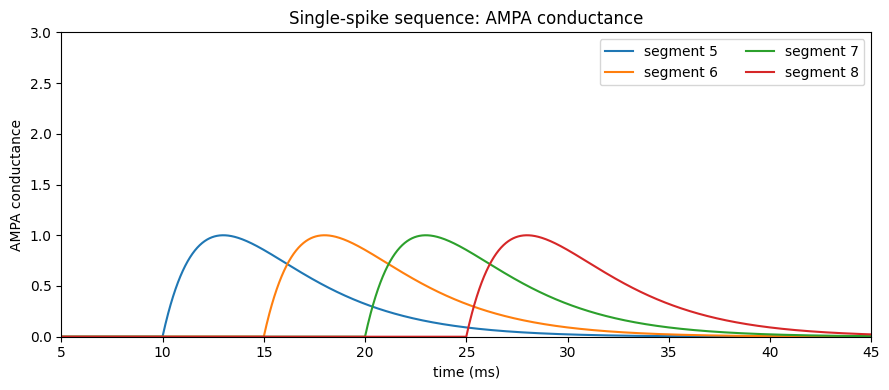

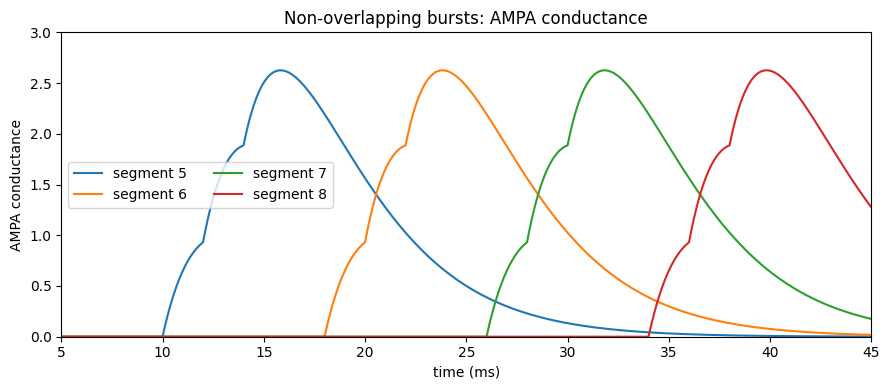

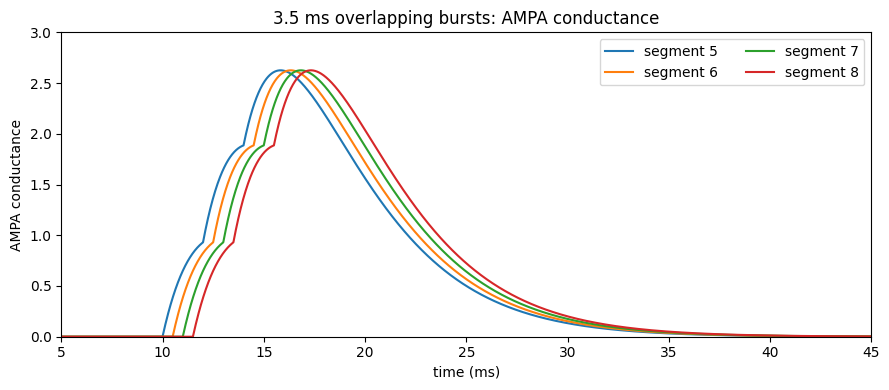

In [ ]:
plot_conductance_history(
    times,
    G_ampa_single,
    sequence_segments,
    title="Single-spike sequence: AMPA conductance",
    ylabel="AMPA conductance",
    xlim=xlim_ampa,
    ylim=ylim_ampa,
)

plot_conductance_history(
    times,
    G_ampa_non,
    sequence_segments,
    title="Non-overlapping bursts: AMPA conductance",
    ylabel="AMPA conductance",
    xlim=xlim_ampa,
    ylim=ylim_ampa,
)

plot_conductance_history(
    times,
    G_ampa_overlap,
    sequence_segments,
    title="3.5 ms overlapping bursts: AMPA conductance",
    ylabel="AMPA conductance",
    xlim=xlim_ampa,
    ylim=ylim_ampa,
)